<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Tomato Leaf Disease Detection
    <br>By Hemingweb
</div>

![](https://images.ctfassets.net/cnu0m8re1exe/RPMZGjwlFNGvhqu6ZG6Gi/8bd5ed7cebc7021562f0da9b5209efac/AI.jpg?fm=jpg&fl=progressive&w=660&h=433&fit=fill)

<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Importing Libs
</div>

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import losses, optimizers, layers
from keras.preprocessing import image_dataset_from_directory, image
from keras.applications import MobileNetV3Large
from keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Loading Data
</div>

In [2]:
BATCH = 32

SIZE = (128, 128)

train_dir = "/kaggle/input/tomatoleaf/tomato/train"

val_dir = "/kaggle/input/tomatoleaf/tomato/val"

train_dataset = image_dataset_from_directory(
    train_dir,
    shuffle = True,
    seed = 123,
    labels = "inferred",
    label_mode = "categorical",
    batch_size = BATCH,
    image_size = SIZE
)

test_dataset = image_dataset_from_directory(
    val_dir,
    shuffle = True,
    seed = 123,
    labels = "inferred",
    label_mode = "categorical",
    validation_split = 0.5,
    subset = "training",
    batch_size = BATCH,
    image_size = SIZE
)

val_dataset = image_dataset_from_directory(
    val_dir,
    shuffle = True,
    seed = 123,
    labels = "inferred",
    label_mode = "categorical",
    validation_split = 0.5,
    subset = "validation",
    batch_size = BATCH,
    image_size = SIZE
)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.
Using 500 files for training.
Found 1000 files belonging to 10 classes.
Using 500 files for validation.


<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Data Visualization
</div>

['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


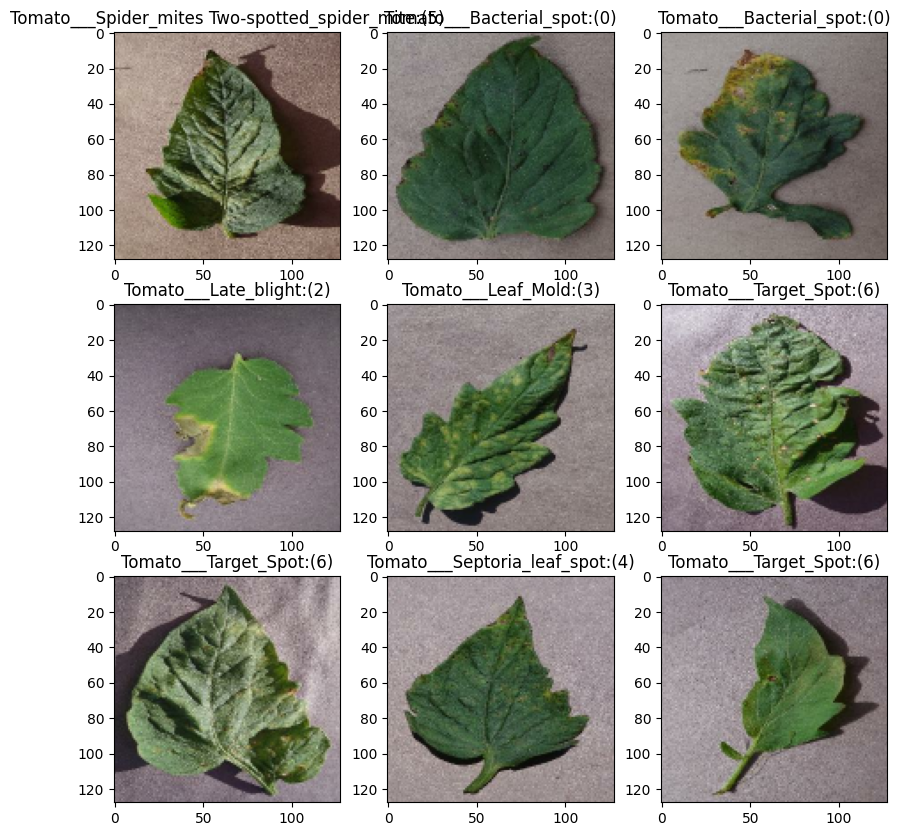

In [3]:
class_name = train_dataset.class_names

print(class_name)

for images, labels in train_dataset.take(1):
  plt.figure(figsize = (10,10))
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label_index = labels[i].numpy().argmax()
    plt.title(f"{class_name[label_index]}:({label_index})")
  plt.show()

<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Data Distribution
</div>

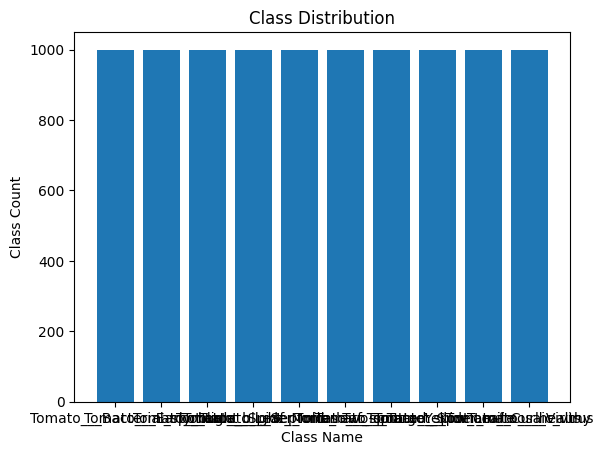

In [4]:
class_count = np.zeros(len(class_name), dtype = int)

for images, labels in train_dataset:
  for label in labels:
    label_index = label.numpy().argmax()
    class_count[label_index] += 1

plt.bar(class_name, class_count)
plt.xlabel("Class Name")
plt.ylabel("Class Count")
plt.title("Class Distribution")
plt.show()

<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Model Loading and Making
</div>

In [5]:
def preprocess(dataset):
  return dataset.map(lambda x, y: (preprocess_input(x),y))

pre_model = MobileNetV3Large(
    weights = "imagenet",
    include_top = False,
    input_shape = (128,128,3)
)

pre_model.trainable = False

x = pre_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(1024, activation = "relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation = "relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation = "relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation = "relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(10 , activation = "softmax")(x)

model = keras.Model(inputs = pre_model.input, outputs = output)

model.compile(
    loss = losses.CategoricalCrossentropy(from_logits = False),
    optimizer = optimizers.Adam(learning_rate = 0.001),
    metrics = ["accuracy"]
)

/usr/local/lib/python3.10/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Model Trainig and Testing
</div>

In [6]:
history = model.fit(train_dataset, validation_data = val_dataset, epochs = 60)

history1 = model.evaluate(test_dataset)

Epoch 1/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 0.1841 - loss: 2.3271 - val_accuracy: 0.6680 - val_loss: 1.0480
Epoch 2/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6344 - loss: 1.0717 - val_accuracy: 0.8480 - val_loss: 0.5116
Epoch 3/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7781 - loss: 0.7123 - val_accuracy: 0.8860 - val_loss: 0.3999
Epoch 4/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8326 - loss: 0.5704 - val_accuracy: 0.8880 - val_loss: 0.3468
Epoch 5/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8474 - loss: 0.5236 - val_accuracy: 0.9200 - val_loss: 0.2823
Epoch 6/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8712 - loss: 0.4432 - val_accuracy: 0.9000 - val_loss: 0.3210
Epoch 7/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8807 - loss: 0.4112 - val_accuracy: 0.9280 - val_loss: 0.2597
Epoch 8/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8946 - loss: 0.3628 - val_acc

<div style="border: 2px solid #ff6347; padding: 20px; background-color: #ffebee; border-radius: 10px; box-shadow: 3px 3px 5px #888888; text-align: center; font-size: 24px; font-weight: bold;">
Model Saving
</div>

In [7]:
model.save("tomato_leaf.h5")
print("model saved")

model saved
